In [333]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mne.time_frequency import psd_array_welch
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from matplotlib import colors
from typing import List, Optional, Tuple, Dict

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")
print(f"MNE version: {mne.__version__}")

Libraries imported successfully!
MNE version: 1.10.1


## Functions

In [334]:
def load_eeg_data(patient: str, dbs_freq: int, base_path: str) -> tuple:
    # Function to load EEG data based on patient ID, DBS frequency, and sleep state
    # Placeholder implementation
    file_path_sleep = f"{base_path}/{patient}/{patient}SLEEP{dbs_freq}.EDF"
    file_path_awake = f"{base_path}/{patient}/{patient}AWAKE{dbs_freq}.EDF"
    raw_sleep = mne.io.read_raw_edf(file_path_sleep, preload=True, verbose=False)
    raw_awake = mne.io.read_raw_edf(file_path_awake, preload=True, verbose=False)
    return raw_sleep, raw_awake

In [335]:
def print_eeg_info(raw):
    print("\n" + "="*60)
    print(f"EEG DATA INFORMATION FOR {raw.info['subject_info']['his_id']}")
    print("="*60)
    print(raw.info)
    print("\nCHANNELS:")
    print(raw.ch_names)
    print("\nDATA DURATION:")
    print(f"{raw.times[-1] / 60:.2f} minutes ({raw.times[-1] / 3600:.2f} hours)")
    print("\nSAMPLING FREQUENCY:")
    print(f"{raw.info['sfreq']} Hz")
    print("\nNUMBER OF CHANNELS:")
    print(f"{len(raw.ch_names)} channels")

In [336]:
def set_custom_channel_types(raw_object):
    """
    Sets channel types for an MNE Raw object based on custom naming conventions.

    This function categorizes channels as 'eeg', 'emg', 'ecg', or 'misc'
    and modifies the Raw object in-place.

    Parameters
    ----------
    raw_object : mne.io.Raw
        The MNE Raw object to be modified.
    """
    # Define the standard 10-20 EEG channel names
    eeg_10_20 = {
        'Fp1', 'F7', 'T3', 'T5', 'O1', 'F3', 'C3', 'P3', 'Fz', 'Cz', 'Fp2',
        'F8', 'T4', 'T6', 'O2', 'F4', 'C4', 'P4', 'Pz',
        'A1', 'A2'
    } # Using a set for faster lookups
    
    ext_eeg = {'T1', 'T2', 'Fpz'}

    # Use a dictionary comprehension for a more concise approach
    ch_types = {
        ch: 'eeg' if ch in eeg_10_20
        else 'eeg' if ch in ext_eeg
        else 'emg' if ch.startswith('EMG')
        else 'ecg' if ch.startswith('EKG')
        else 'eog' if ch.startswith('LOC') or ch.startswith('ROC')
        else 'misc'
        for ch in raw_object.ch_names
    }

    raw_object.set_channel_types(ch_types)
    print(f"Channel types set for {len(raw_object.ch_names)} channels.")

In [337]:
def set_reference(raw_object, ref_channels: list or str = 'average'):
    """
    Sets the reference for an MNE Raw object.

    This function applies a common average reference or a specified reference
    channel to the Raw object in-place.

    Parameters
    ----------
    raw_object : mne.io.Raw
        The MNE Raw object to be modified.
    ref_channels : list or str
        List of channel names to use as reference or 'average' for common average reference.
    """
    raw_object.set_eeg_reference(ref_channels=ref_channels)
    print(f"Reference set using channels: {ref_channels}")

In [338]:
def plot_timeseries_custom(raw: mne.io.Raw,
                           picks: Optional[List[str]] = None,
                           start: float = 0,
                           duration: float = 10,
                           title: Optional[str] = None,
                           figsize: Tuple[float, float] = (15, 10),
                           show: bool = True):
    """
    Generates a high-quality, customizable time series plot and returns the figure.

    Defaults to plotting all EEG channels if no 'picks' are provided.
    Allows for custom figure size.

    Parameters
    ----------
    raw : mne.io.Raw
        The MNE Raw object containing the data.
    picks : list of str, optional
        A specific list of channel names to plot. If None, all 'eeg' channels
        are plotted automatically. Defaults to None.
    start : float, optional
        Start time in seconds for the plot. Defaults to 0.
    duration : float, optional
        Duration of the time window to plot in seconds. Defaults to 10.
    title : str, optional
        Custom title for the plot. If None, a descriptive title is automatically generated.
    figsize : tuple, optional
        The figure size (width, height) in inches. Defaults to (15, 10).
    show : bool, optional
        If True, the plot is displayed automatically. Defaults to True.

    Returns
    -------
    matplotlib.figure.Figure
        The Matplotlib figure object for saving or further modification.
    """
    # --- Flexible Channel Selection ---
    if picks is None:
        # Default mode: Automatically find all EEG channels
        channel_picks = mne.pick_types(raw.info, eeg=True, exclude='bads')
        plot_mode = 'EEG'
        scalings = dict(eeg=50e-6) # Sensible default scaling for EEG
    else:
        # Manual mode: Use the provided list of channel names
        channel_picks = picks
        plot_mode = 'Custom'
        scalings = 'auto' # Auto-scale when channel types might be mixed

    if len(channel_picks) == 0:
        print(f"Warning: No channels found to plot for mode '{plot_mode}'. Aborting.")
        return None

    # --- Aesthetics for a Nicer Plot ---
    plt.style.use('seaborn-v0_8-whitegrid')
    channel_color = dict(all='darkslateblue')

    # --- Smart Title Generation ---
    if title is None:
        title = f"{plot_mode} Channels ({len(channel_picks)} selected) from {start:.1f}s to {start + duration:.1f}s"

    # --- Generate the Plot ---
    fig = raw.plot(
        picks=channel_picks,
        start=start,
        duration=duration,
        title=title,
        scalings=scalings,
        color=channel_color,
        show=False, # Must be False to allow for customization before showing
        n_channels=len(channel_picks)
    )

    # --- Apply Customizations ---
    fig.set_size_inches(figsize) # Set the custom figure size
    fig.set_facecolor('white')   # Ensure a clean white background
    plt.tight_layout()           # Adjust layout to prevent labels from overlapping

    if show:
        plt.show()

    return fig

In [339]:
def set_eeg_montage(raw_object, montage_name: str = 'standard_1020'):
    """
    Sets the EEG montage for an MNE Raw object.

    This function applies a standard EEG montage to the Raw object in-place.

    Parameters
    ----------
    raw_object : mne.io.Raw
        The MNE Raw object to be modified.
    montage_name : str
        Name of the standard montage to apply. Defaults to 'standard_1020'.
    """
    try:
        montage = mne.channels.make_standard_montage('standard_1020')
        raw_object.set_montage(montage, on_missing='warn')
        print("Montage set successfully!")
    except Exception as e:
        print(f"Error setting montage: {e}")

In [340]:
def apply_frequency_filter(raw: mne.io.Raw,
                       l_freq: Optional[float] = None,
                       h_freq: Optional[float] = None,
                       filter_length: str = 'auto',
                       powerline_freq: Optional[float] = None,
                       fir_design: str = 'firwin') -> mne.io.Raw:
    """
    Apply a classic DSP filter to the EEG data.

    Parameters
    ----------
    raw : mne.io.Raw
        The MNE Raw object containing the EEG data.
    l_freq : float | None
        The lower frequency bound for the filter (in Hz).
    h_freq : float | None
        The upper frequency bound for the filter (in Hz).
    filter_length : str
        The length of the filter (e.g., 'auto', '10s', etc.).
    fir_design : str
        The design method for the FIR filter (e.g., 'firwin', 'firls', etc.).

    Returns
    -------
    mne.io.Raw
        The filtered MNE Raw object.
    """
    # Apply the filter
    raw.filter(l_freq=l_freq, h_freq=h_freq, fir_design=fir_design)
    # Remove power line noise (it can be 50-60Hz depending on region)
    if powerline_freq is not None:
        raw.notch_filter(freqs=powerline_freq, fir_design=fir_design)
    print(f"Applied bandpass filter: {l_freq} - {h_freq} Hz")

### Visualization

In [341]:
def plot_channel_comparison(raw1: mne.io.Raw,
                            start1: float,
                            raw2: mne.io.Raw,
                            start2: float,
                            channel_name: str,
                            duration: float = 5.0,
                            label1: str = 'Segment 1',
                            label2: str = 'Segment 2',
                            figsize: Tuple[float, float] = (15, 8)):
    """
    Compares two different time segments for a single channel on side-by-side subplots.

    The segments can be from the same or different Raw objects.

    Parameters
    ----------
    raw1 : mne.io.Raw
        The first MNE Raw object.
    start1 : float
        The start time (in seconds) of the first segment.
    raw2 : mne.io.Raw
        The second MNE Raw object. Can be the same as raw1.
    start2 : float
        The start time (in seconds) of the second segment.
    channel_name : str
        The name of the channel to plot (e.g., 'Cz').
    duration : float, optional
        The duration (in seconds) for both plot windows. Defaults to 5.0.
    label1 : str, optional
        The label/title for the first subplot. Defaults to 'Segment 1'.
    label2 : str, optional
        The label/title for the second subplot. Defaults to 'Segment 2'.
    figsize : tuple, optional
        The figure size (width, height) in inches. Defaults to (15, 8).

    Returns
    -------
    matplotlib.figure.Figure
        The Matplotlib figure object containing the plots.
    """
    # --- Validate that the channel exists in both objects ---
    if channel_name not in raw1.ch_names or channel_name not in raw2.ch_names:
        print(f"Error: Channel '{channel_name}' must exist in both Raw objects.")
        return None

    # --- Prepare data for the first segment ---
    start_samp1, stop_samp1 = raw1.time_as_index([start1, start1 + duration])
    times1 = raw1.times[start_samp1:stop_samp1]
    data1 = raw1.get_data(picks=[channel_name], start=start_samp1, stop=stop_samp1)[0] * 1e6 # Convert to µV

    # --- Prepare data for the second segment ---
    start_samp2, stop_samp2 = raw2.time_as_index([start2, start2 + duration])
    times2 = raw2.times[start_samp2:stop_samp2]
    data2 = raw2.get_data(picks=[channel_name], start=start_samp2, stop=stop_samp2)[0] * 1e6 # Convert to µV

    # --- Create the Plot ---
    plt.style.use('seaborn-v0_8-whitegrid')
    # Use sharey=True for direct amplitude comparison
    fig, axes = plt.subplots(2, 1, figsize=figsize, sharey=True)
    fig.suptitle(f'Comparison for Channel: {channel_name}', fontsize=16, fontweight='bold')

    # Plot Segment 1
    axes[0].plot(times1, data1, color='cornflowerblue', linewidth=0.8)
    axes[0].set_title(label1, fontsize=14)
    axes[0].set_ylabel('Amplitude (µV)')
    axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)

    # Plot Segment 2
    axes[1].plot(times2, data2, color='indianred', linewidth=0.8)
    axes[1].set_title(label2, fontsize=14)
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Amplitude (µV)')
    axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)

    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout for the main title
    plt.show()

    return fig

In [342]:
import mne
import matplotlib.pyplot as plt
import numpy as np
from typing import List, Tuple, Optional

def plot_psd_comparison(freqs_raw: np.ndarray,
                        psd_raw: np.ndarray,
                        freqs_filt: np.ndarray,
                        psd_filt: np.ndarray,
                        channel_name: str,
                        artifact_freqs: Optional[List[float]] = None,
                        fmin: float = 0.0,
                        fmax: float = 100.0,
                        figsize: Tuple[float, float] = (15, 10)):
    """
    Compares the Power Spectral Density (PSD) of raw and filtered data.

    Allows for a customizable frequency range on the x-axis and highlights
    specified artifact frequencies.

    Parameters
    ----------
    freqs_raw, psd_raw : np.ndarray
        Frequency and PSD arrays for the raw data.
    freqs_filt, psd_filt : np.ndarray
        Frequency and PSD arrays for the filtered data.
    channel_name : str
        The name of the channel being plotted.
    artifact_freqs : list of float, optional
        A list of frequencies to mark with vertical lines (e.g., [60, 120]).
    fmin, fmax : float, optional
        The minimum and maximum frequency to display on the x-axis.
        Defaults to a range of 0-100 Hz.
    figsize : tuple, optional
        The figure size (width, height) in inches. Defaults to (15, 10).

    Returns
    -------
    matplotlib.figure.Figure
        The Matplotlib figure object.
    """
    # --- Create the Plot ---
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True, sharey=True)
    fig.suptitle(f'PSD Comparison for Channel: {channel_name}', fontsize=16, fontweight='bold')

    # --- Plot Raw Data PSD ---
    axes[0].semilogy(freqs_raw, psd_raw, color='cornflowerblue', linewidth=1.5, label='Raw PSD')
    axes[0].set_title('Before Filtering', fontsize=14)
    axes[0].set_ylabel('Power (µV²/Hz)')
    axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)

    # --- Plot Filtered Data PSD ---
    axes[1].semilogy(freqs_filt, psd_filt, color='forestgreen', linewidth=1.5, label='Filtered PSD')
    axes[1].set_title('After Filtering', fontsize=14)
    axes[1].set_xlabel('Frequency (Hz)')
    axes[1].set_ylabel('Power (µV²/Hz)')
    axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)

    # --- Add Artifact Lines to Both Plots ---
    colors = ['red', 'orange', 'purple']
    if artifact_freqs:
        for i, freq in enumerate(artifact_freqs):
            # Add line to raw plot with a clear label
            label = f'{freq} Hz Artifact'
            axes[0].axvline(freq, color=colors[i % len(colors)], linestyle='--',
                            linewidth=1.5, label=label, alpha=0.7)
            # Add matching line to filtered plot (without label) for reference
            axes[1].axvline(freq, color=colors[i % len(colors)], linestyle='--',
                            linewidth=1.5, alpha=0.5)

    # Add legends after all lines have been added
    axes[0].legend(loc='upper right')
    axes[1].legend(loc='upper right')

    # --- Apply Final Settings ---
    # Set the custom frequency range on the x-axis
    axes[1].set_xlim(fmin, fmax)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    return fig

In [343]:
def plot_band_power_topomaps(raw_object: mne.io.Raw,
                             band_powers: Dict[str, np.ndarray],
                             suptitle: str = "Topographic Distribution of Band Powers",
                             save_path: Optional[str] = None):
    """
    Plots the topographic distribution of power for different frequency bands.

    If channels with standard 10-20 positions are not found, it automatically
    creates fallback bar plots instead.

    Parameters
    ----------
    raw_object : mne.io.Raw
        The MNE Raw object, used for channel information.
    band_powers : dict
        A dictionary where keys are band names (e.g., 'Alpha') and values are
        NumPy arrays of the power for each channel.
    suptitle : str, optional
        The main title for the entire figure.
    save_path : str, optional
        The file path to save the figure. If None, the figure is not saved.
        Example: 'my_figure.png'.

    Returns
    -------
    matplotlib.figure.Figure
        The Matplotlib figure object created.
    """
    try:
        # --- Attempt to Create Topographic Plots ---
        montage = mne.channels.make_standard_montage('standard_1020')
        standard_channels = set(montage.ch_names)

        # Find channels in the data that have a standard 10-20 position
        available_channels = [ch for ch in raw_object.ch_names if ch in standard_channels]

        if not available_channels:
            raise ValueError("No channels with standard 10-20 positions were found.")

        print(f"Found {len(available_channels)} channels with standard positions for plotting.")

        # Create a temporary Raw object with only these channels and set the montage
        raw_temp = raw_object.copy().pick(available_channels)
        raw_temp.set_montage(montage, on_missing='warn')

        # Get the indices of these channels from the original Raw object
        ch_indices = [raw_object.ch_names.index(ch) for ch in available_channels]

        # Filter the band_powers dictionary to only include these channels
        topo_band_powers = {band: powers[ch_indices] for band, powers in band_powers.items()}

        # --- Plotting ---
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        axes = axes.flatten()

        for idx, (band_name, powers) in enumerate(topo_band_powers.items()):
            im, _ = mne.viz.plot_topomap(powers, raw_temp.info, axes=axes[idx], show=False,
                                         cmap='viridis', contours=6)
            axes[idx].set_title(band_name, fontsize=14, fontweight='bold')
            cbar = plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)
            cbar.set_label('Power (µV²)', rotation=270, labelpad=15)

        # Clean up unused subplot if necessary
        if len(band_powers) < len(axes):
            for i in range(len(band_powers), len(axes)):
                fig.delaxes(axes[i])

        fig.suptitle(suptitle, fontsize=18, fontweight='bold')
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])


    except Exception as e:
        # --- Fallback to Bar Plots ---
        print(f"\nCould not create topographic plots: {e}")
        print("Creating alternative bar plots instead...")

        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        axes = axes.flatten()

        for idx, (band_name, powers) in enumerate(band_powers.items()):
            axes[idx].bar(raw_object.ch_names, powers)
            axes[idx].set_title(band_name, fontsize=14, fontweight='bold')
            axes[idx].set_ylabel('Band Power (µV²)')
            axes[idx].grid(True, axis='y', alpha=0.5)
            plt.setp(axes[idx].get_xticklabels(), rotation=90, ha='right')

        if len(band_powers) < len(axes):
            for i in range(len(band_powers), len(axes)):
                fig.delaxes(axes[i])

        fig.suptitle(f"{suptitle} (Bar Plot Fallback)", fontsize=18, fontweight='bold')
        plt.tight_layout()

    # --- Save and Show ---
    if save_path:
        print(f"Saving figure to {save_path}...")
        plt.savefig(save_path, dpi=300)
    plt.show()

    return fig

### Frequency analysis

In [344]:
def get_psd(raw: mne.io.Raw,
            fmin: float = 0.5,
            fmax: float = 40.0,
            n_fft: int = 2048,
            n_overlap: int = 512,
            n_per_seg: int = 1024) -> tuple:
    """
    Compute the Power Spectral Density (PSD) of EEG data using Welch's method.

    Parameters
    ----------
    raw : mne.io.Raw
        The MNE Raw object containing the EEG data.
    fmin : float
        Minimum frequency of interest (in Hz).
    fmax : float
        Maximum frequency of interest (in Hz).
    n_fft : int
        Length of the FFT used.
    n_overlap : int
        Number of points to overlap between segments.
    n_per_seg : int
        Length of each segment.

    Returns
    -------
    tuple
        Frequencies and corresponding PSD values.
    """
    picks = mne.pick_types(raw.info, eeg=True, exclude='bads')
    data, times = raw[picks, :]
    psds, freqs = psd_array_welch(data, sfreq=raw.info['sfreq'], fmin=fmin, fmax=fmax,
                                  n_fft=n_fft, n_overlap=n_overlap, n_per_seg=n_per_seg)
    return freqs, psds

In [345]:
import pandas as pd
import numpy as np
from typing import Dict, Tuple, List, Optional

def calculate_band_powers(psd: np.ndarray,
                          freqs: np.ndarray,
                          ch_names: List[str],
                          bands: Optional[Dict[str, Tuple[float, float]]] = None) -> pd.DataFrame:
    """
    Calculates the power for specified frequency bands from PSD data.

    Parameters
    ----------
    psd : np.ndarray
        The Power Spectral Density data, with shape (n_channels, n_freqs).
    freqs : np.ndarray
        The frequency bins corresponding to the PSD data.
    ch_names : list of str
        A list of channel names that MUST match the channels in the psd array.
    bands : dict, optional
        A dictionary defining the frequency bands. If None, default EEG bands
        are used.

    Returns
    -------
    pd.DataFrame
        A DataFrame containing the band power for each channel and band.
    """
    # --- Robustness Check ---
    # Ensure the number of channels in the PSD array matches the number of channel names
    if psd.shape[0] != len(ch_names):
        raise ValueError(
            f"Mismatch in dimensions: PSD has data for {psd.shape[0]} channels, "
            f"but {len(ch_names)} channel names were provided."
        )

    # Use default EEG bands if none are provided
    if bands is None:
        bands = {
            'Delta (0.5-4 Hz)': (0.5, 4), 'Theta (4-8 Hz)': (4, 8),
            'Alpha (8-13 Hz)': (8, 13), 'Beta (13-30 Hz)': (13, 30),
            'Gamma (30-40 Hz)': (30, 40)
        }

    band_powers = {}
    for band, (fmin, fmax) in bands.items():
        freq_indices = np.where((freqs >= fmin) & (freqs <= fmax))[0]
        # Use dx=np.diff(freqs)[0] for a more robust integration step
        band_powers[band] = np.trapz(psd[:, freq_indices], dx=np.diff(freqs)[0], axis=1)

    band_power_df = pd.DataFrame(band_powers, index=ch_names)
    band_power_df.index.name = 'Channel'
    return band_power_df

## EEG Pipeline

### Preprocessing


#### Load data

In [346]:
# start with XU 7 DBS
patient = "XU"
dbs_freq = 7  # in Hz
base_path = "../data"
raw_sleep, raw_awake = load_eeg_data(patient, dbs_freq, base_path)

In [347]:
print_eeg_info(raw_sleep)


EEG DATA INFORMATION FOR X
<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, F7, T3, T5, O1, F3, C3, P3, A1, Fz, Cz, Fp2, F8, T4, T6, ...
 chs: 46 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2025-05-11 00:22:15 UTC
 nchan: 46
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, first_name: X, last_name: X>
>

CHANNELS:
['Fp1', 'F7', 'T3', 'T5', 'O1', 'F3', 'C3', 'P3', 'A1', 'Fz', 'Cz', 'Fp2', 'F8', 'T4', 'T6', 'O2', 'F4', 'C4', 'P4', 'A2', 'Fpz', 'Pz', 'T1', 'T2', 'EKGL', 'EKGR', 'LOC1', 'LOC2', 'EMG1', 'EMG2', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'DC1', 'DC2', 'DC3', 'DC4', 'OSAT', 'PR']

DATA DURATION:
10.63 minutes (0.18 hours)

SAMPLING FREQUENCY:
256.0 Hz

NUMBER OF CHANNELS:
46 channels


In [348]:
print_eeg_info(raw_awake)


EEG DATA INFORMATION FOR X
<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, F7, T3, T5, O1, F3, C3, P3, A1, Fz, Cz, Fp2, F8, T4, T6, ...
 chs: 46 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2025-05-10 18:55:25 UTC
 nchan: 46
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, first_name: X, last_name: X>
>

CHANNELS:
['Fp1', 'F7', 'T3', 'T5', 'O1', 'F3', 'C3', 'P3', 'A1', 'Fz', 'Cz', 'Fp2', 'F8', 'T4', 'T6', 'O2', 'F4', 'C4', 'P4', 'A2', 'Fpz', 'Pz', 'T1', 'T2', 'EKGL', 'EKGR', 'LOC1', 'LOC2', 'EMG1', 'EMG2', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'DC1', 'DC2', 'DC3', 'DC4', 'OSAT', 'PR']

DATA DURATION:
9.47 minutes (0.16 hours)

SAMPLING FREQUENCY:
256.0 Hz

NUMBER OF CHANNELS:
46 channels


#### set channel type

In [349]:
set_custom_channel_types(raw_sleep)
set_custom_channel_types(raw_awake)

Channel types set for 46 channels.
Channel types set for 46 channels.


##### Plot

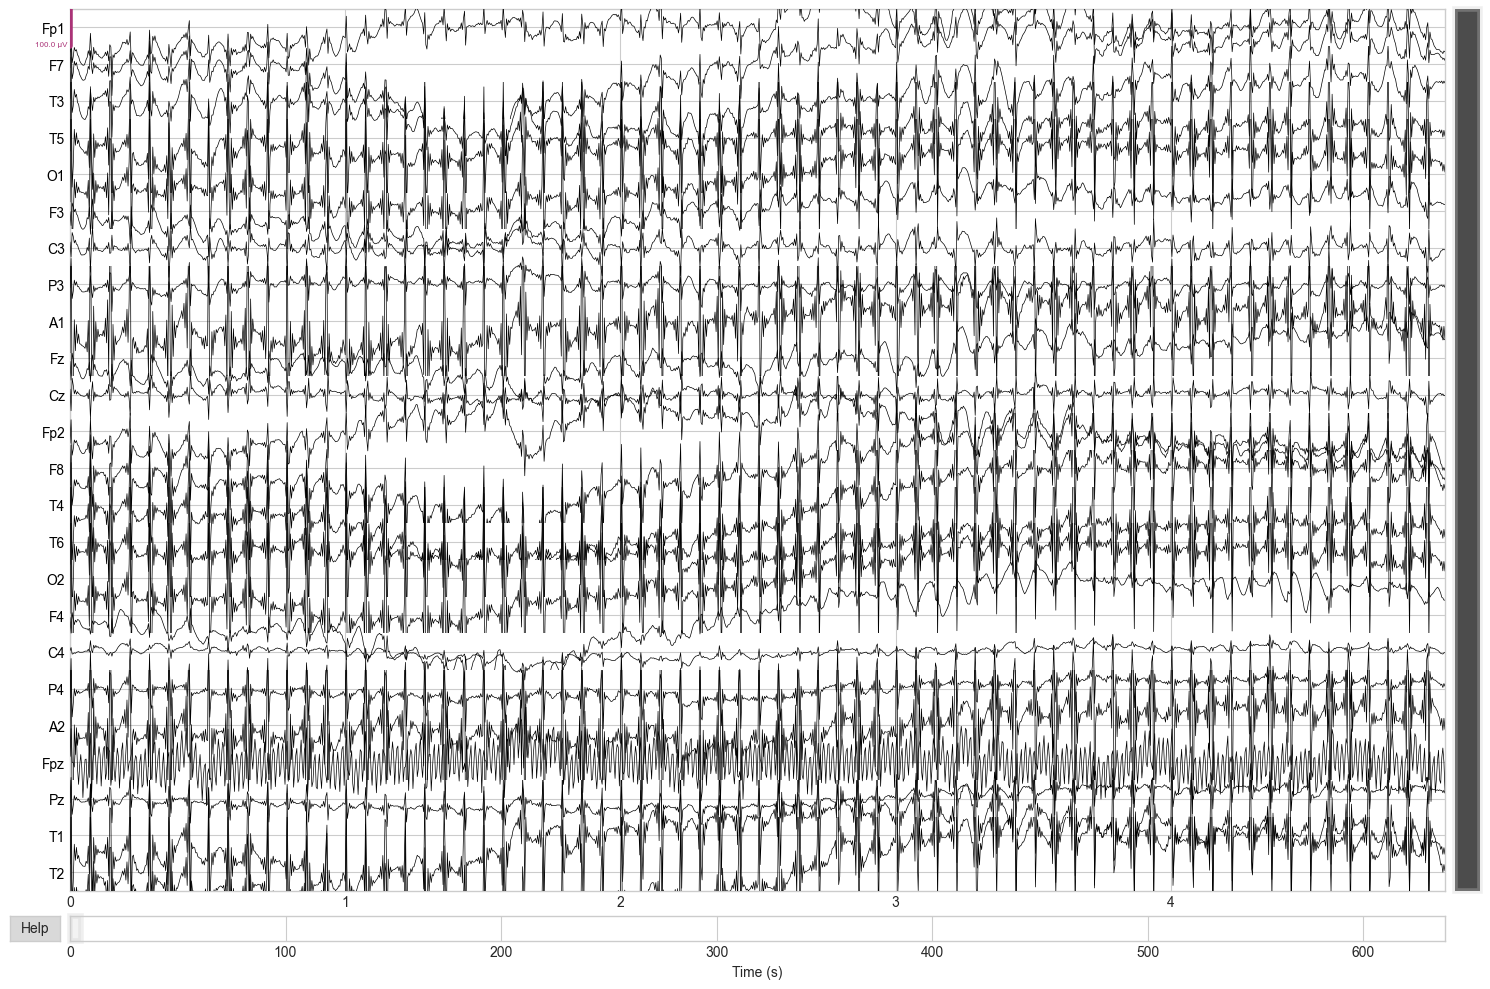

In [350]:
fig_xu7_sleep = plot_timeseries_custom(raw_sleep, start=0, duration=5, title="XU 7Hz DBS Sleep EEG", show=True)

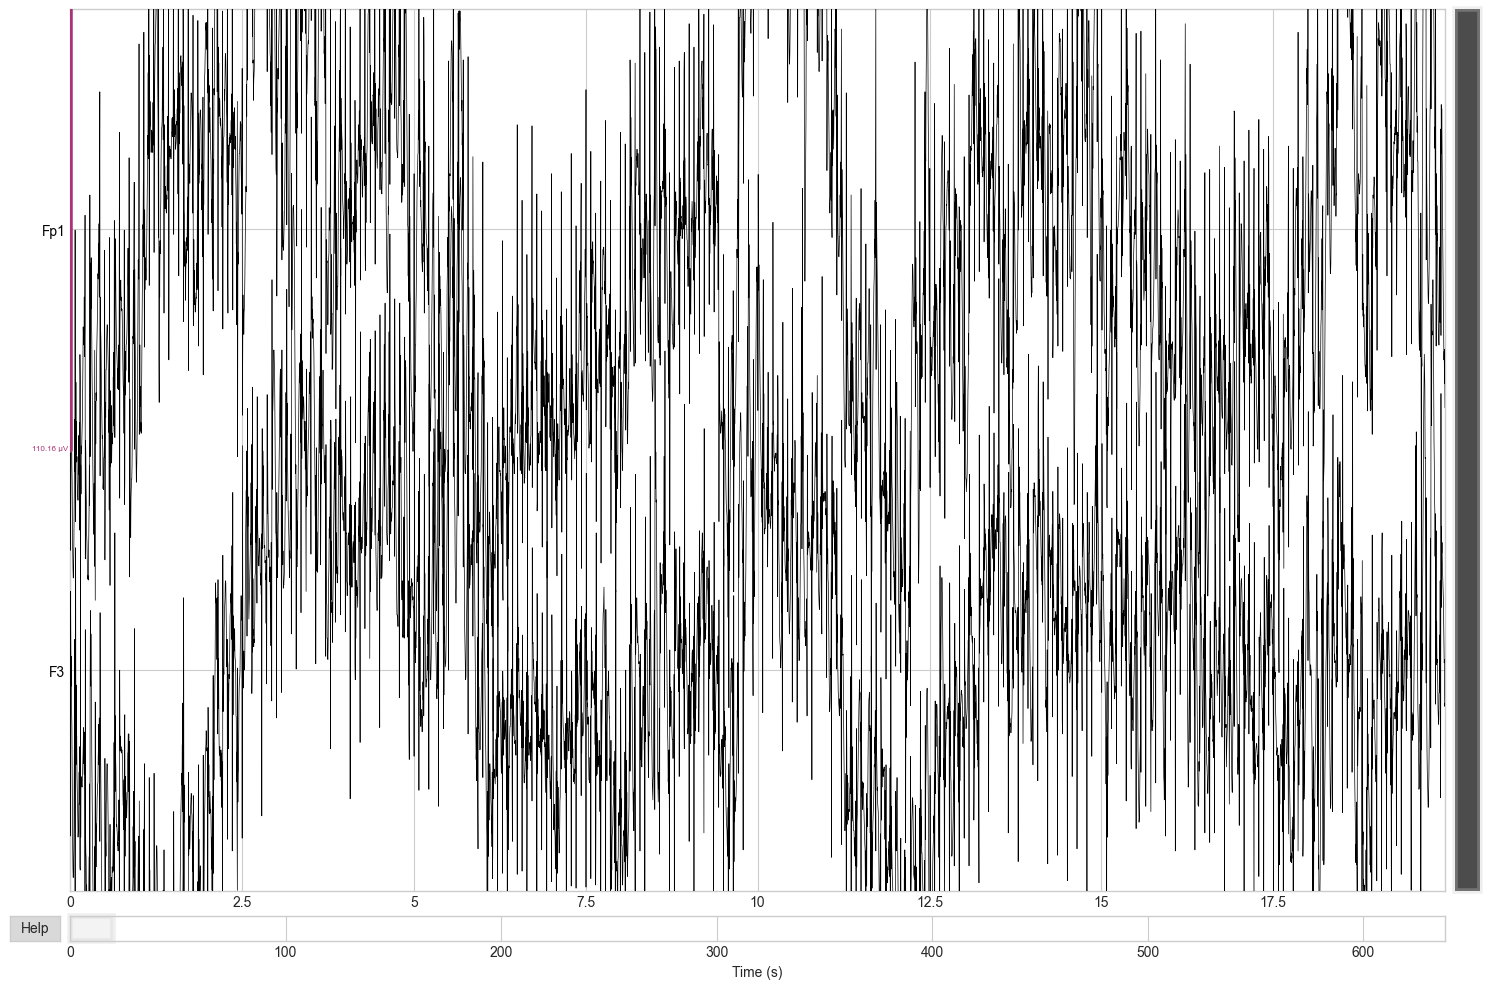

In [351]:
fig_xu7_sleep = plot_timeseries_custom(raw_sleep, start=0, duration=20, title="XU 7Hz DBS Sleep EEG", show=True, picks=['Fp1', 'F3'] )

#### Set ref channel

In [352]:
ref = ['A1', 'A2']
set_reference(raw_sleep, ref_channels=ref)
set_reference(raw_awake, ref_channels=ref)

EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Reference set using channels: ['A1', 'A2']
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Reference set using channels: ['A1', 'A2']


#### Plot

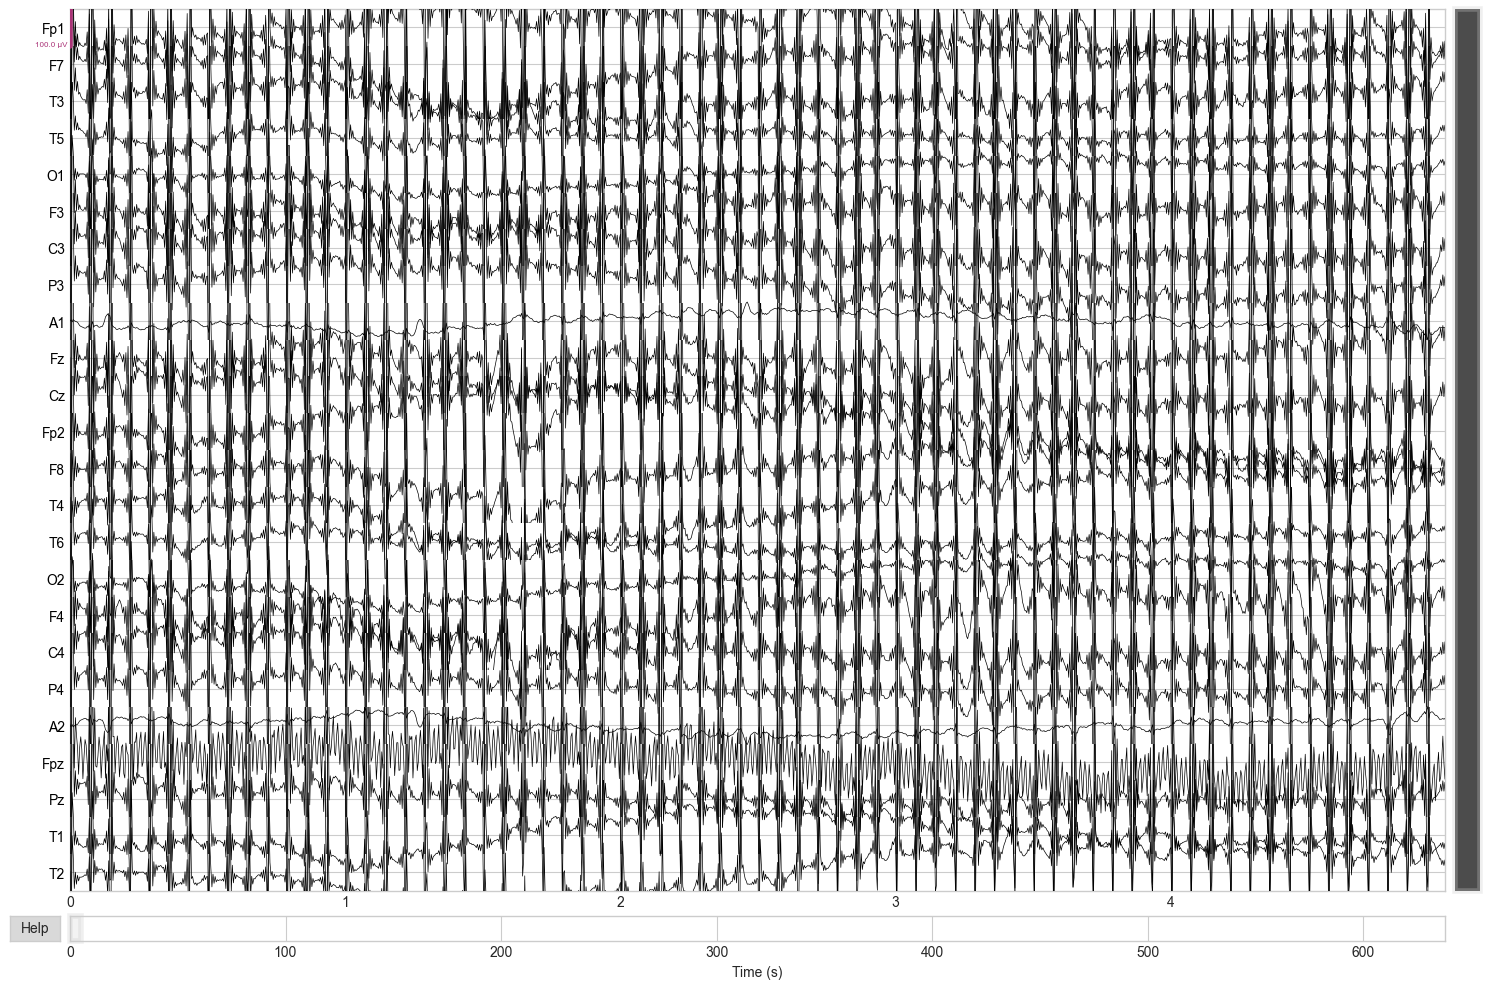

In [353]:
fig_xu7_sleep = plot_timeseries_custom(raw_sleep, start=0, duration=5, title="XU 7Hz DBS Sleep EEG", show=True)

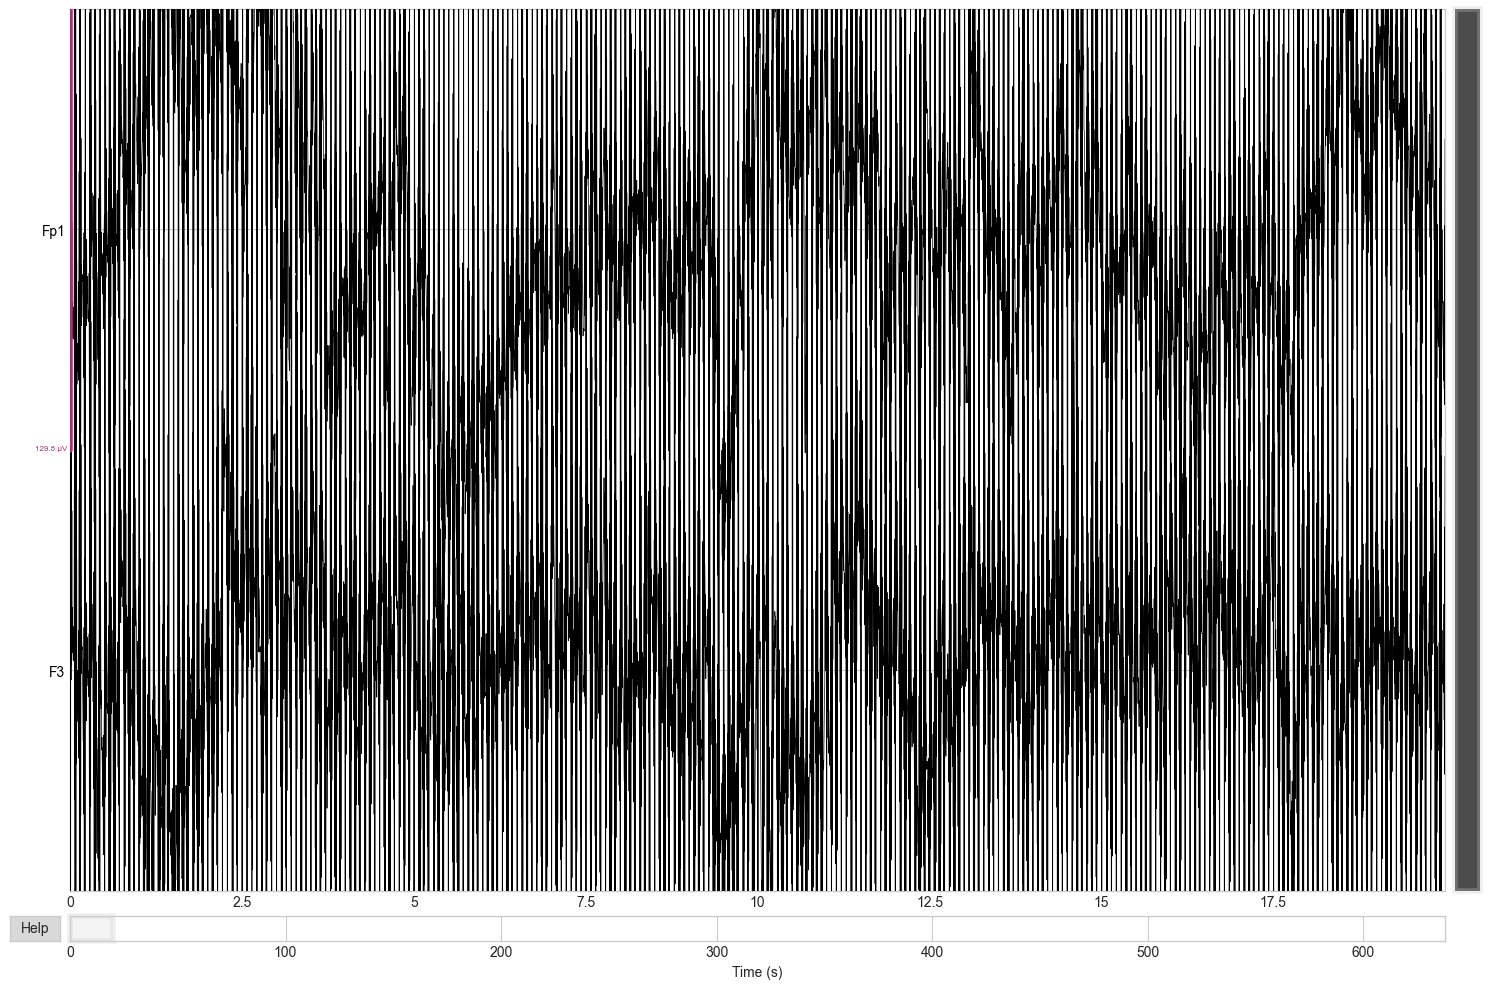

In [354]:
fig_xu7_sleep = plot_timeseries_custom(raw_sleep, start=0, duration=20, title="XU 7Hz DBS Sleep EEG", show=True, picks=['Fp1', 'F3'] )

#### Set montage

In [355]:
set_eeg_montage(raw_sleep)
set_eeg_montage(raw_awake)

Montage set successfully!
Montage set successfully!


## Filtering

### Apply freq filter
Classic band pass filtering

In [356]:
raw_awake_filtered = raw_awake.copy()
raw_sleep_filtered = raw_sleep.copy()

In [380]:
apply_frequency_filter(raw_sleep_filtered, l_freq=0.5, h_freq=40.0, powerline_freq=60.0)
apply_frequency_filter(raw_awake_filtered, l_freq=0.5, h_freq=40.0, powerline_freq=60.0)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (6.605 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband e

#### Plot

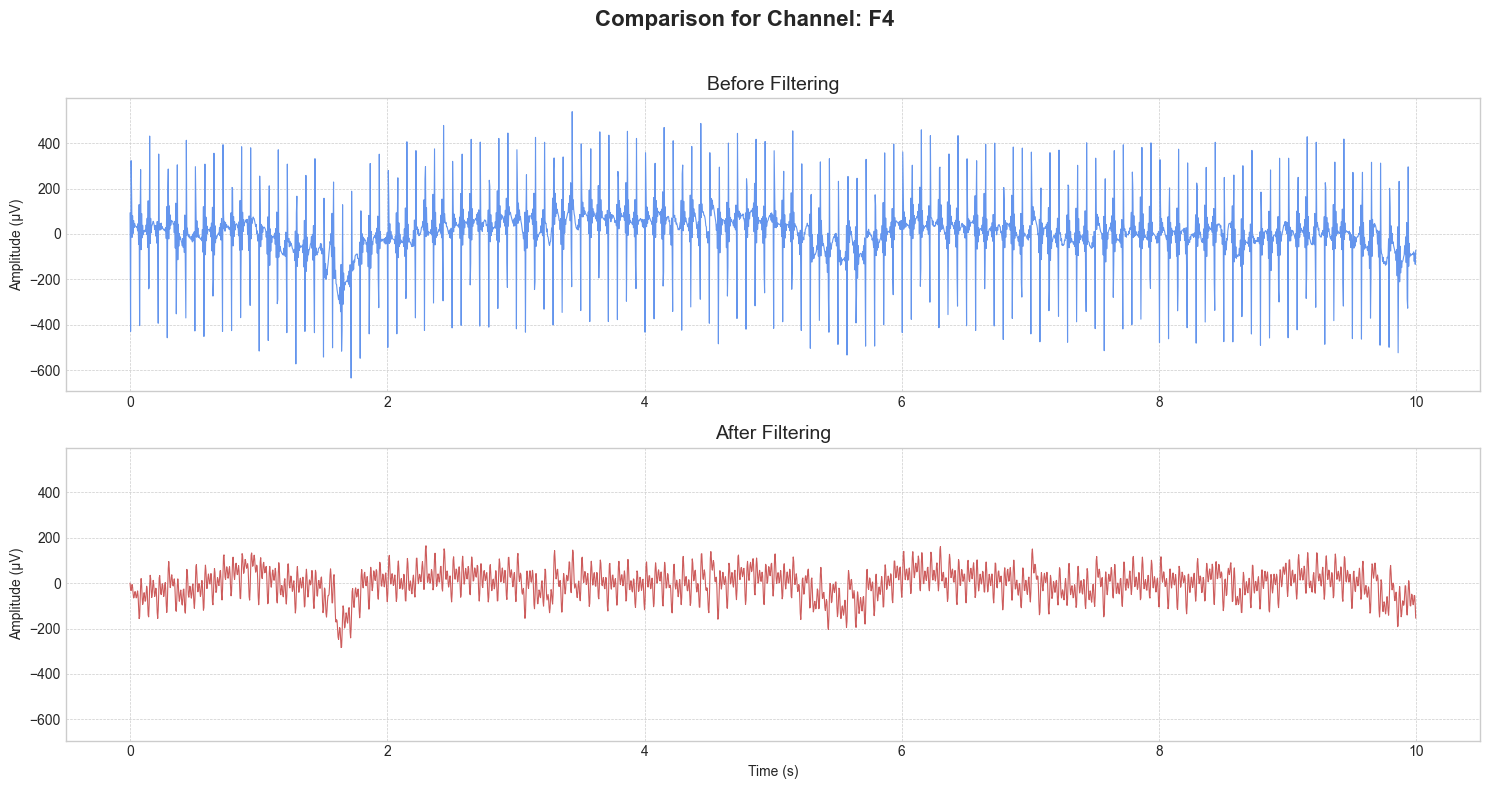

In [381]:
fig_xu7_sleep = plot_channel_comparison(
    raw1=raw_sleep,
    start1=0,
    raw2=raw_sleep_filtered,
    start2=0,
    channel_name='F4',
    duration=10.0,
    label1='Before Filtering',
    label2='After Filtering',
    figsize=(15, 8)
)

### Calculate PSD test

In [359]:
raw_psd_sleep_freqs, raw_psd_sleep_values = get_psd(raw_sleep_filtered)
raw_psd_awake_freqs, raw_psd_awake_values = get_psd(raw_awake_filtered)

Effective window size : 8.000 (s)
Effective window size : 8.000 (s)


In [360]:
filtered_psd_sleep_freqs, filtered_psd_sleep_values = get_psd(raw_sleep_filtered)
filtered_psd_awake_freqs, filtered_psd_awake_values = get_psd(raw_awake_filtered)

Effective window size : 8.000 (s)
Effective window size : 8.000 (s)


#### Plots

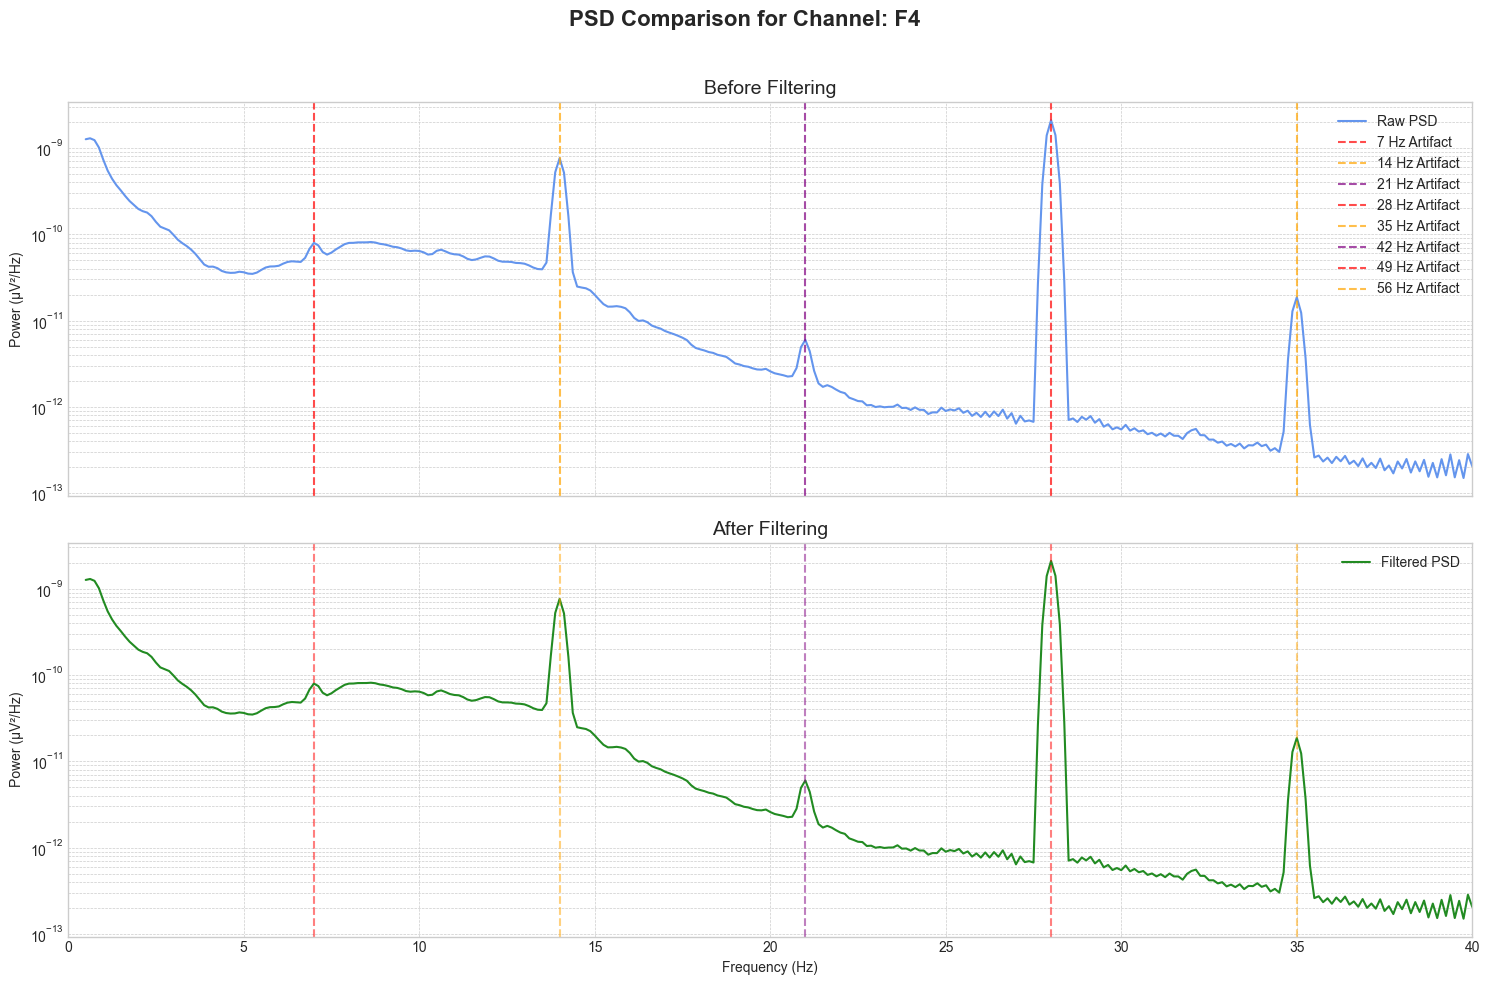

In [361]:
fig = plot_psd_comparison(
    freqs_raw=raw_psd_sleep_freqs,
    psd_raw=raw_psd_sleep_values[raw_sleep.ch_names.index('F4')],
    freqs_filt=filtered_psd_sleep_freqs,
    psd_filt=filtered_psd_sleep_values[raw_sleep.ch_names.index('F4')],
    channel_name='F4',
    artifact_freqs=[7,14,21,28,35,42,49,56],
    figsize=(15, 10),
    fmin=0.0,
    fmax=40.0
)

In [362]:
eeg_channels = [ch for ch in raw_sleep_filtered.ch_names if raw_sleep_filtered.get_channel_types([ch])[0] == 'eeg']
eeg_channels

['Fp1',
 'F7',
 'T3',
 'T5',
 'O1',
 'F3',
 'C3',
 'P3',
 'A1',
 'Fz',
 'Cz',
 'Fp2',
 'F8',
 'T4',
 'T6',
 'O2',
 'F4',
 'C4',
 'P4',
 'A2',
 'Fpz',
 'Pz',
 'T1',
 'T2']

In [363]:
df_band_powers_sleep = calculate_band_powers(
    psd=filtered_psd_sleep_values,
    freqs=filtered_psd_sleep_freqs,
    ch_names=eeg_channels
)

df_band_powers_awake = calculate_band_powers(
    psd=filtered_psd_awake_values,
    freqs=filtered_psd_awake_freqs,
    ch_names=eeg_channels
)

In [364]:
band_powers_dict_sleep = {band: df_band_powers_sleep[band].values for band in df_band_powers_sleep.columns}

Found 22 channels with standard positions for plotting.


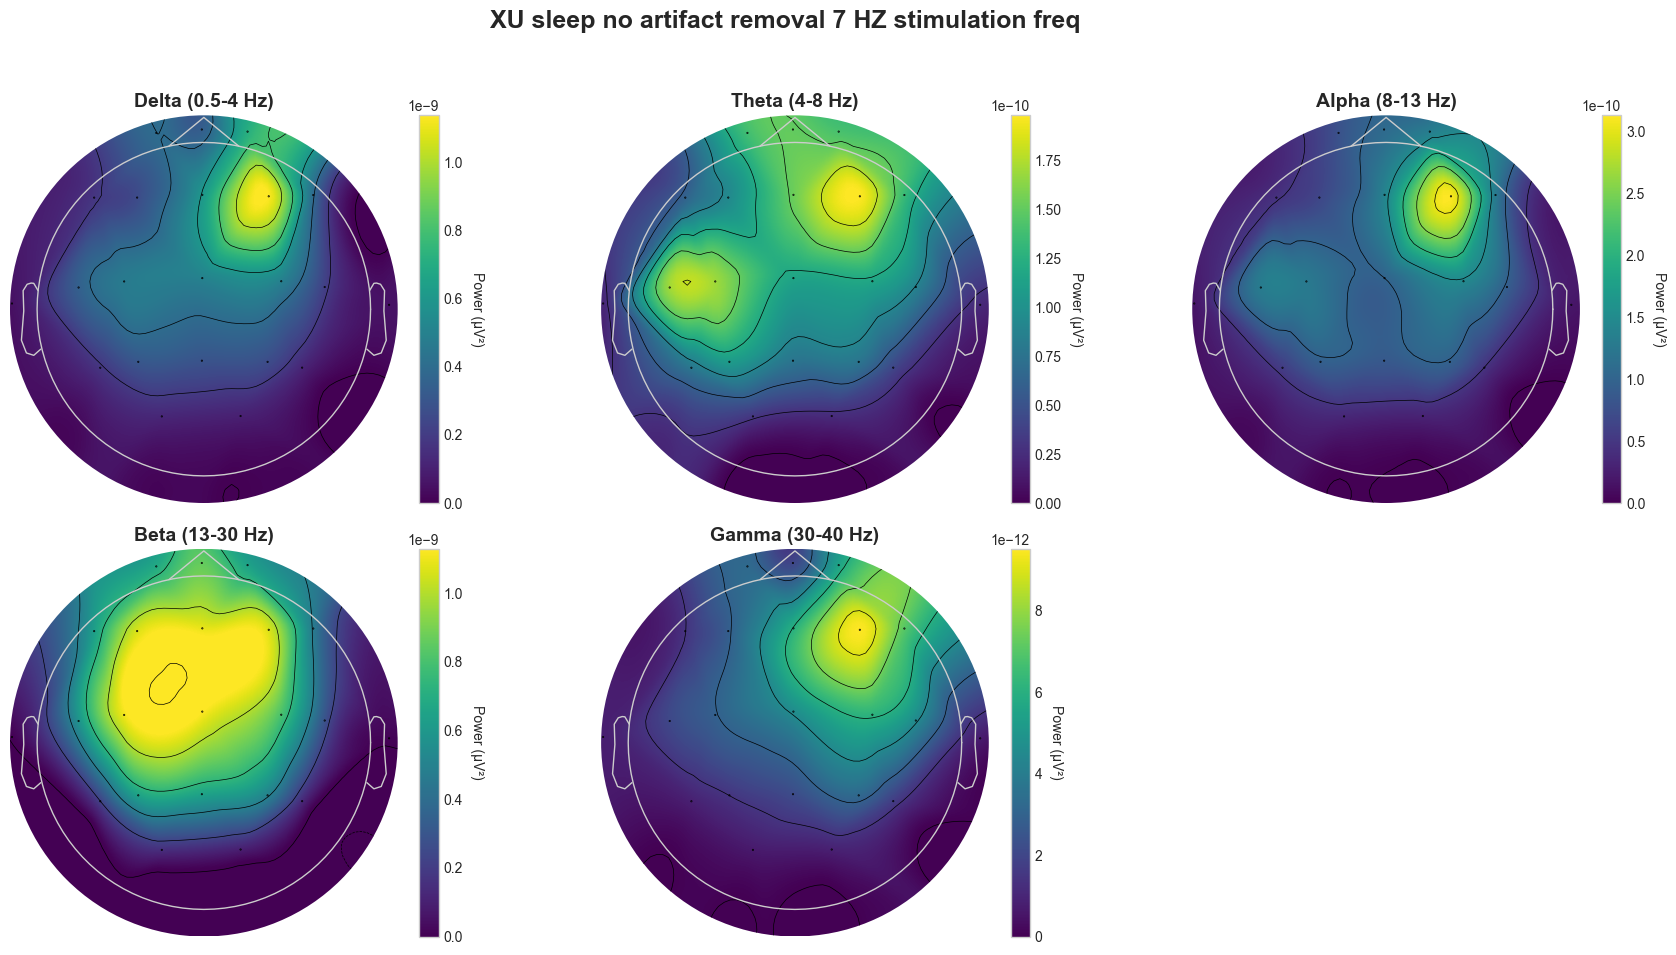

In [365]:
fig = plot_band_power_topomaps(
    raw_object=raw_awake_filtered,
    band_powers=band_powers_dict_sleep,
    suptitle=f'{patient} sleep no artifact removal 7 HZ stimulation freq'
)

In [366]:
band_powers_dict_awake = {band: df_band_powers_awake[band].values for band in df_band_powers_awake.columns}

Found 22 channels with standard positions for plotting.


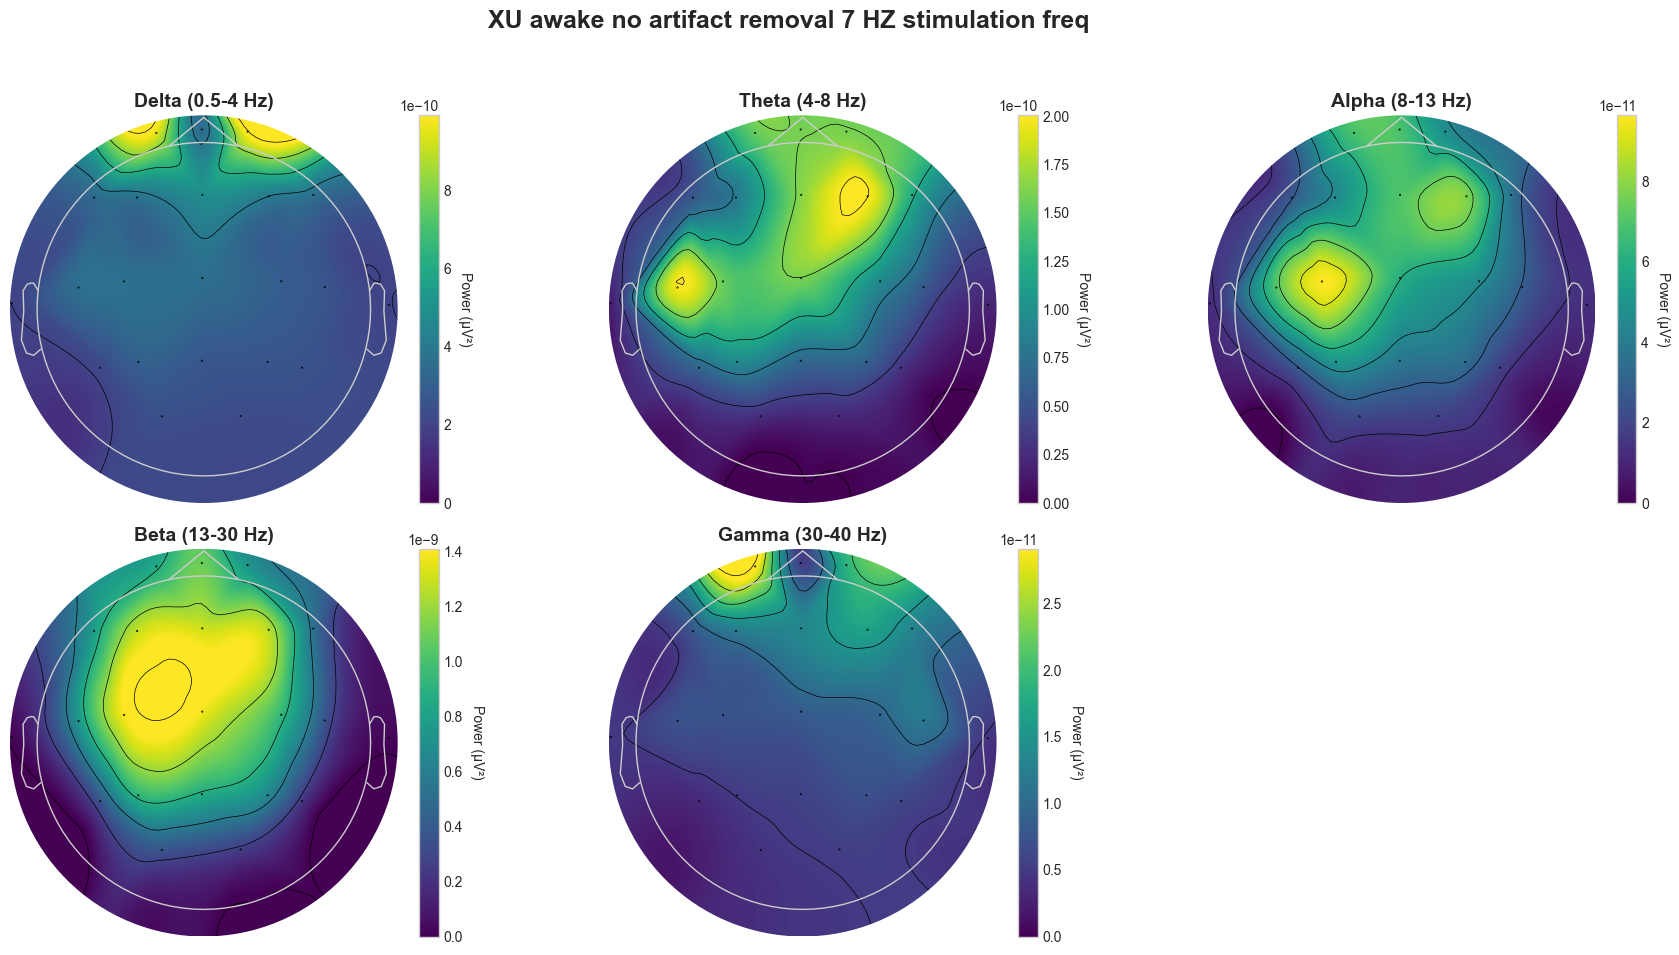

In [367]:
fig = plot_band_power_topomaps(
    raw_object=raw_sleep_filtered,
    band_powers=band_powers_dict_awake,
    suptitle=f'{patient} awake no artifact removal 7 HZ stimulation freq'
)

## Artifact Removal

### Eye blink

In [368]:
raw_awake_for_ica = raw_awake_filtered.copy()
raw_sleep_for_ica = raw_sleep_filtered.copy()
raw_awake_for_ica.drop_channels(['T1', 'T2', 'Fpz'])
raw_sleep_for_ica.drop_channels(['T1', 'T2', 'Fpz'])

<RawEDF | XUSLEEP7.EDF, 43 x 163328 (638.0 s), ~53.6 MiB, data loaded>

In [369]:
raw_awake_for_ica.filter(l_freq=1.0, h_freq=None, fir_design='firwin')
raw_sleep_for_ica.filter(l_freq=1.0, h_freq=None, fir_design='firwin')

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 845 samples (3.301 s)

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 845 samples (3.301 s)



<RawEDF | XUSLEEP7.EDF, 43 x 163328 (638.0 s), ~53.6 MiB, data loaded>

In [370]:
eog_evoked = mne.preprocessing.create_eog_epochs(raw_awake_for_ica).average()

Using EOG channels: LOC1, LOC2
EOG channel index for this subject is: [23 24]
Filtering the data to remove DC offset to help distinguish blinks from saccades
Selecting channel LOC1 for blink detection
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2560 samples (10.000 s)

Now detecting blinks and generating corresponding events
Found 647 significant peaks
Number of EOG events detected: 647
Not setting metadata
647 matching events found
No baseline correction applied
Using data from preloaded Raw for 647 events and 257 original time points ...
1 bad epochs dropped


In [371]:
eog_evoked.apply_baseline(baseline=(None, -0.2))

Applying baseline correction (mode: mean)


<Evoked | '998' (average, N=646), -0.5 – 0.5 s, baseline -0.5 – -0.2 s, 21 ch, ~72 KiB>

No projector specified for this dataset. Please consider the method self.add_proj.


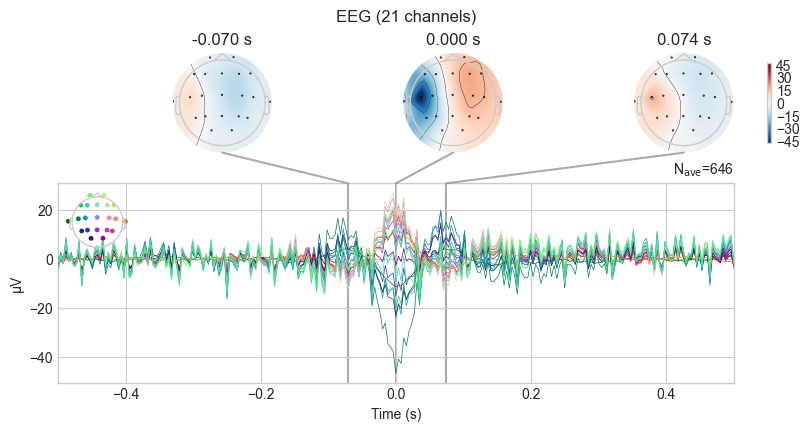

In [372]:
fig =eog_evoked.plot_joint()

Using channel EKGL to identify heart beats.
Setting up band-pass filter from 8 - 16 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 8.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 7.75 Hz)
- Upper passband edge: 16.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 16.25 Hz)
- Filter length: 2560 samples (10.000 s)

Number of ECG events detected : 755 (average pulse 79.75352112676056 / min.)
Not setting metadata
755 matching events found
No baseline correction applied
Using data from preloaded Raw for 755 events and 257 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)
No projector specified for this dataset. Please consider the method self.add_proj.


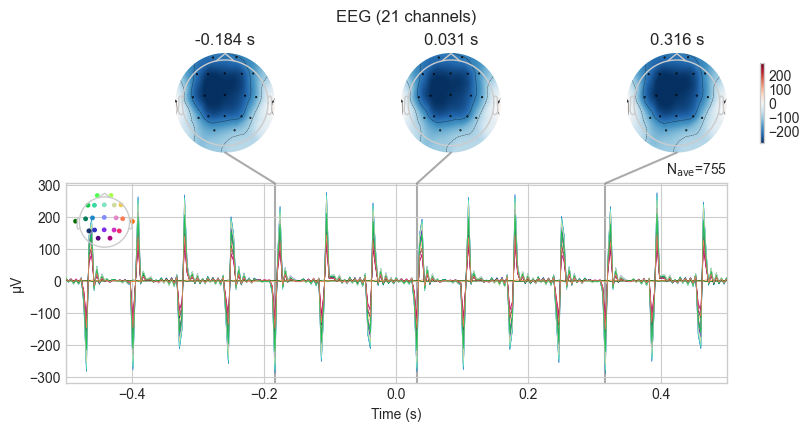

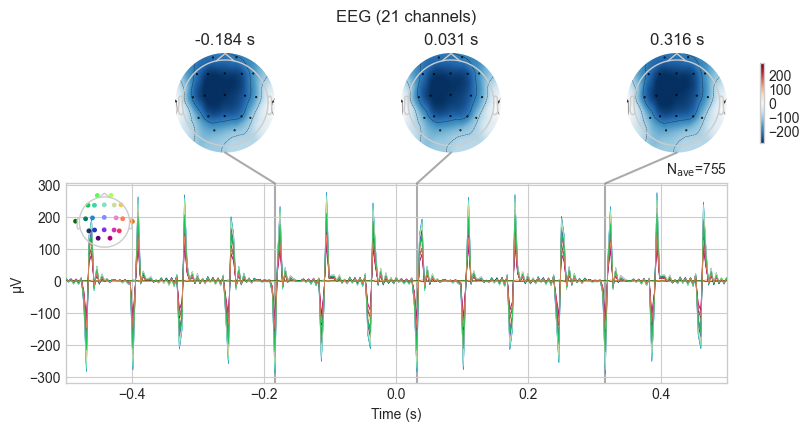

In [373]:
ecg_evoked = mne.preprocessing.create_ecg_epochs(raw_awake_for_ica).average()
ecg_evoked.apply_baseline(baseline=(None, -0.2))
ecg_evoked.plot_joint()

In [374]:
ica = mne.preprocessing.ICA(n_components=15, random_state=97, max_iter='auto')
ica.fit(raw_awake_for_ica)

Fitting ICA to data using 21 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 0.4s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,23 iterations on raw data (145408 samples)
ICA components,15
Available PCA components,21
Channel types,eeg
ICA components marked for exclusion,—


In [375]:
explained_var_ratio = ica.get_explained_variance_ratio(
    raw_awake_for_ica, components=[0], ch_type="eeg"
)
# This time, print as percentage.
ratio_percent = round(100 * explained_var_ratio["eeg"])
print(
    f"Fraction of variance in EEG signal explained by first component: {ratio_percent}%"
)


Fraction of variance in EEG signal explained by first component: 84%


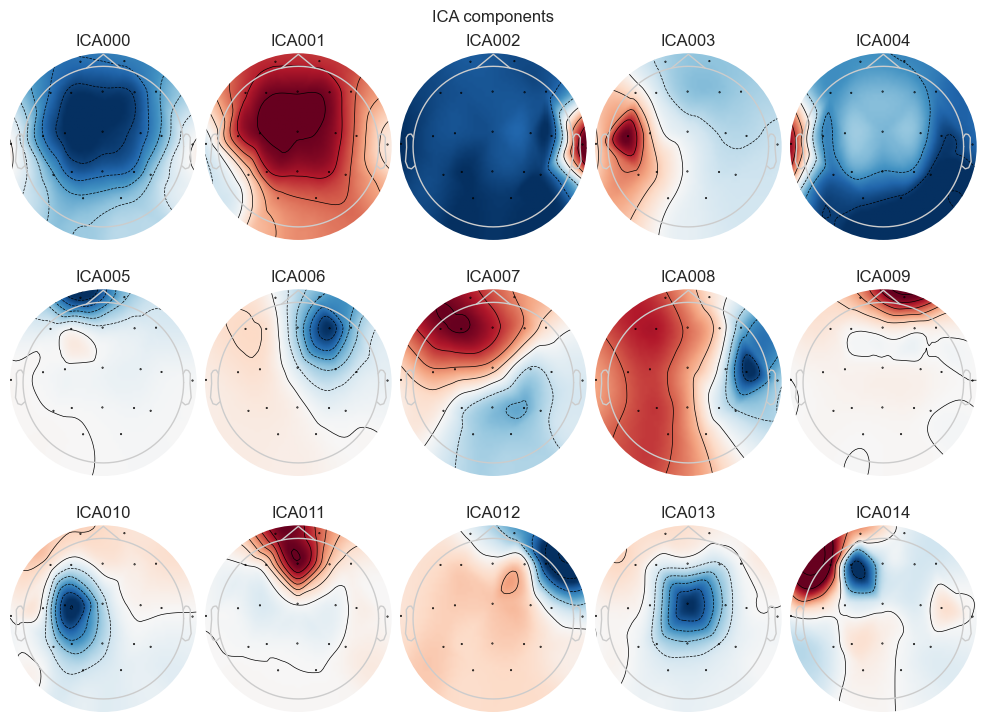

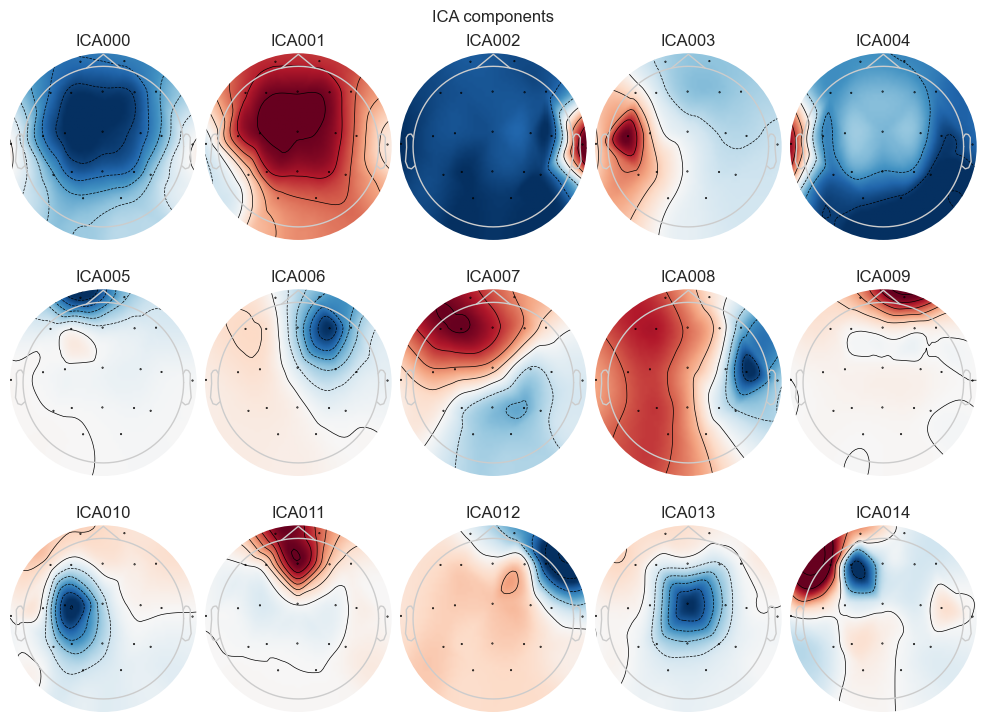

In [376]:
ica.plot_components()

Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 1 ICA component
    Projecting back using 21 PCA components


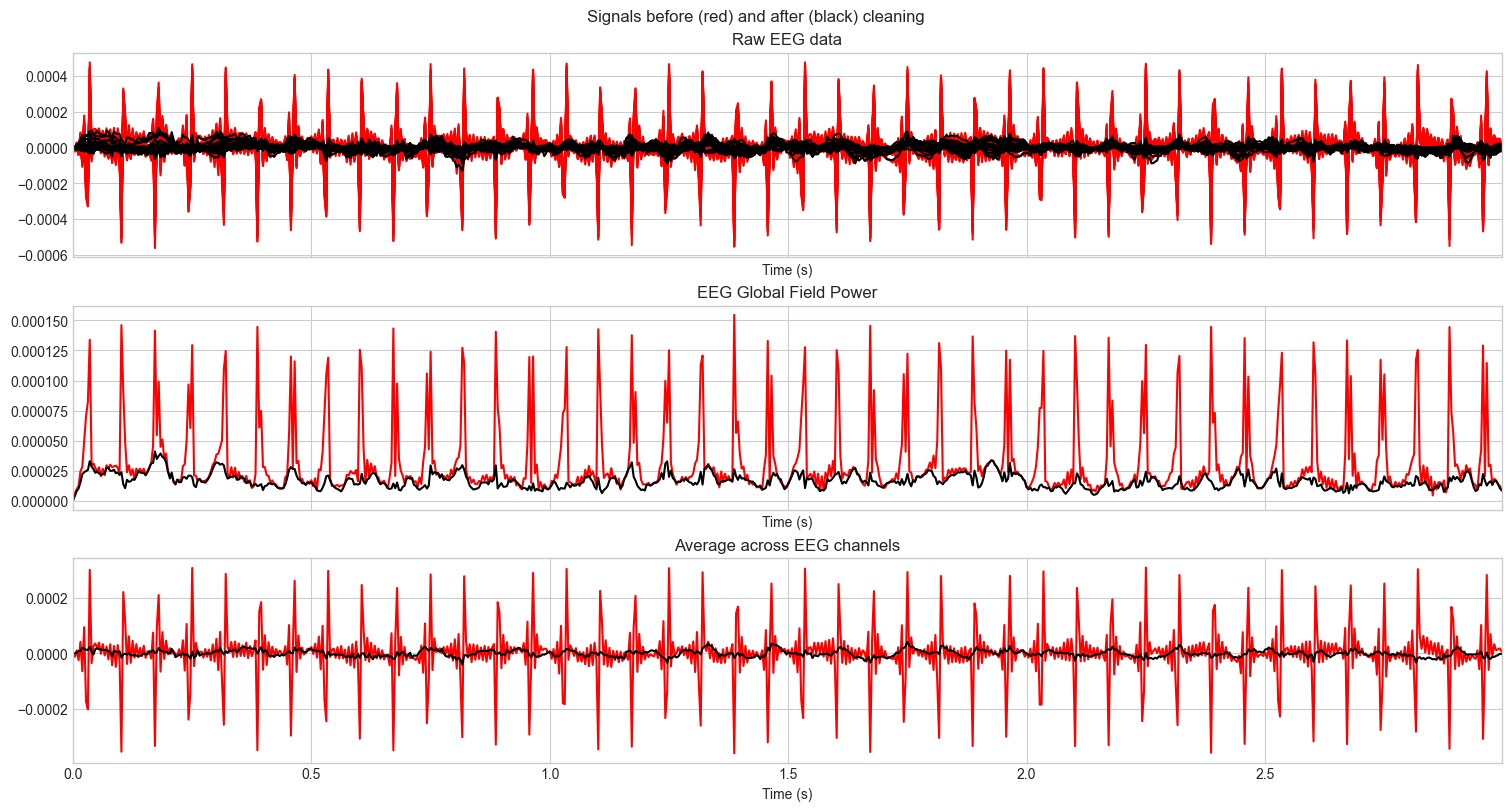

Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 1 ICA component
    Projecting back using 21 PCA components


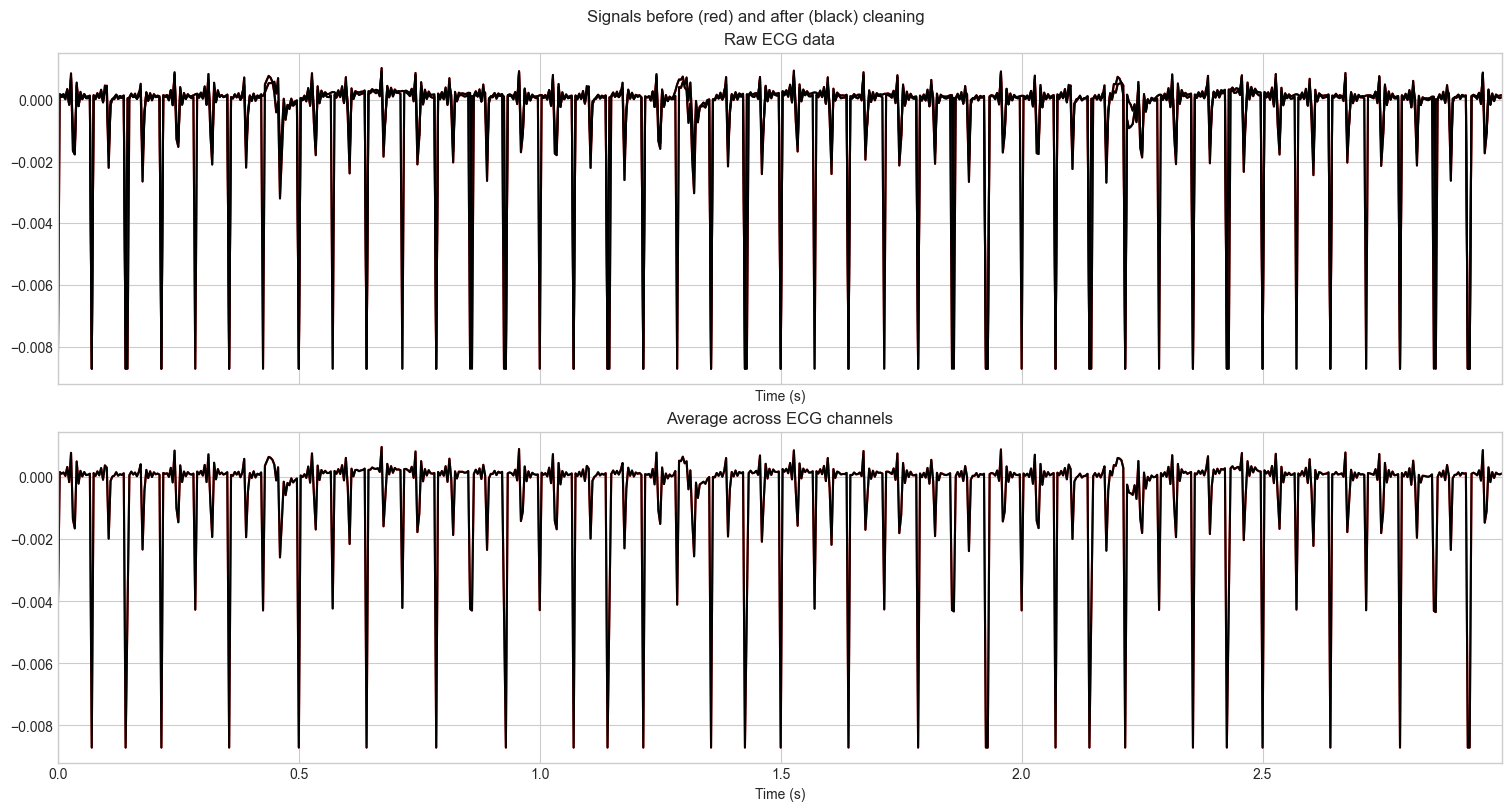

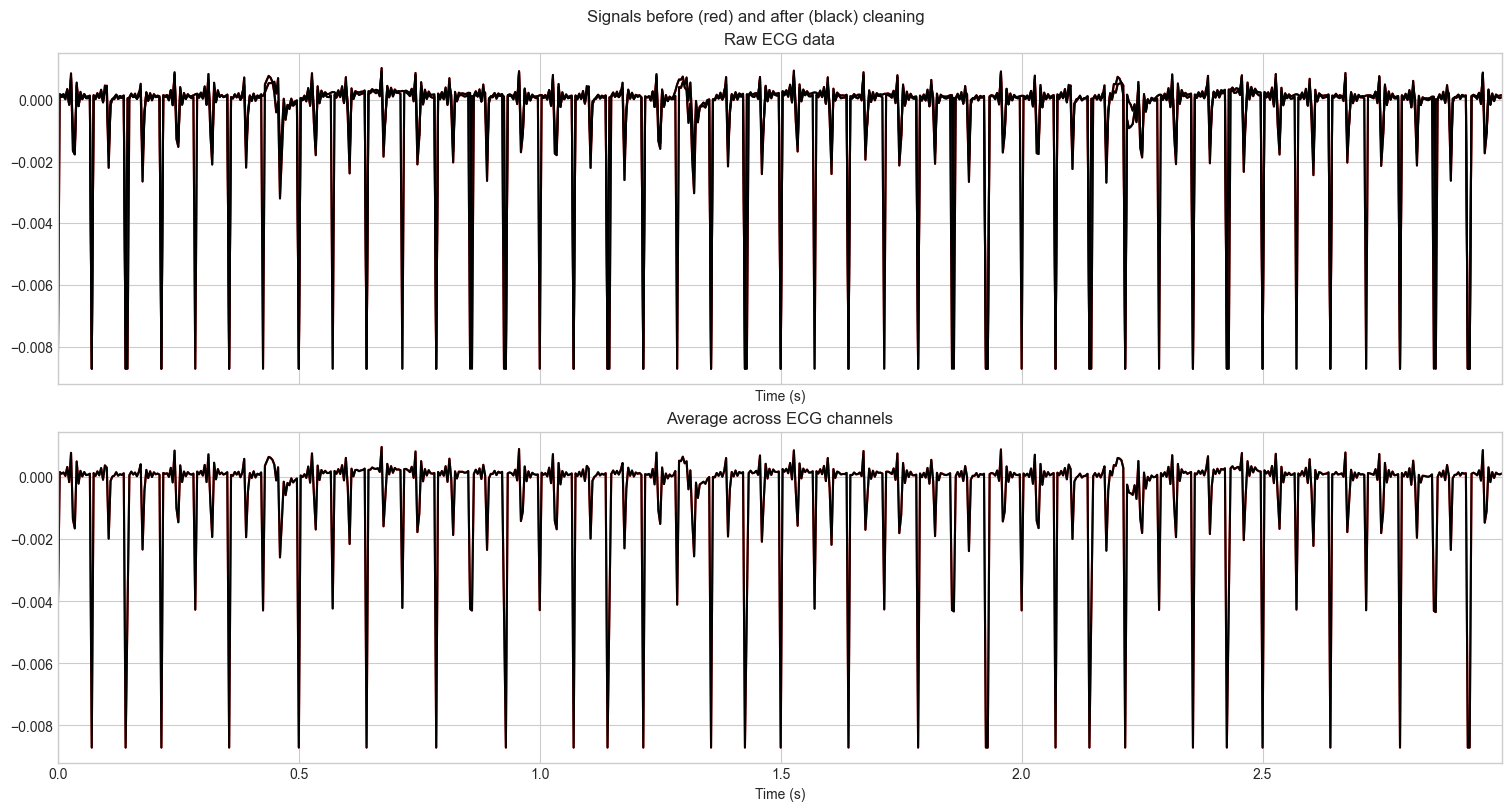

In [377]:
# blinks
ica.plot_overlay(raw_awake_for_ica, exclude=[0], picks="eeg")
# heartbeats
ica.plot_overlay(raw_awake_for_ica, exclude=[1], picks="ecg")

    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
284 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
284 matching events found
No baseline correction applied
0 projection items activated


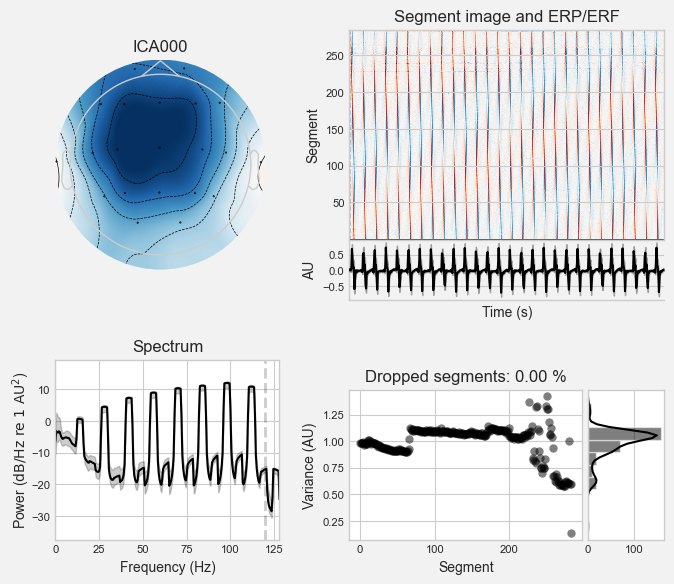

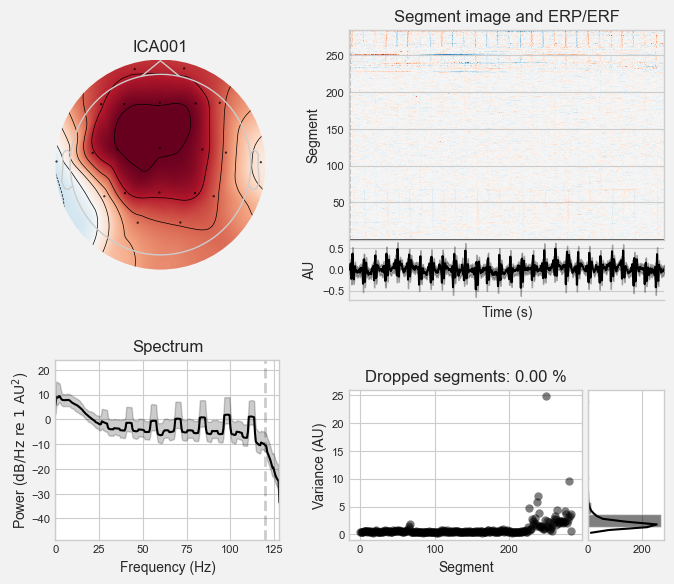

[<Figure size 700x600 with 6 Axes>, <Figure size 700x600 with 6 Axes>]

In [378]:
ica.plot_properties(raw_awake_for_ica, picks=[0, 1])

Using EOG channels: LOC1, LOC2
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2560 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.2

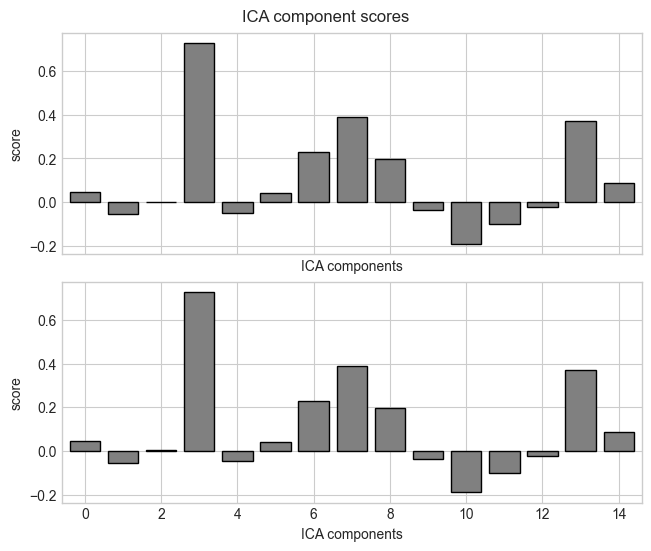

No EOG components found automatically.
Creating RawArray with float64 data, n_channels=19, n_times=145408
    Range : 0 ... 145407 =      0.000 ...   567.996 secs
Ready.


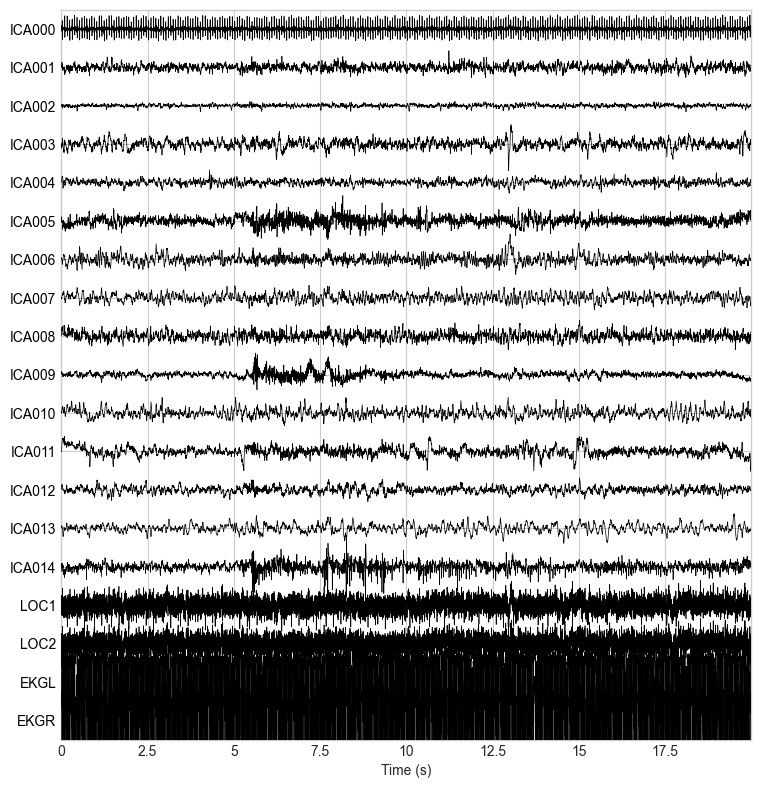

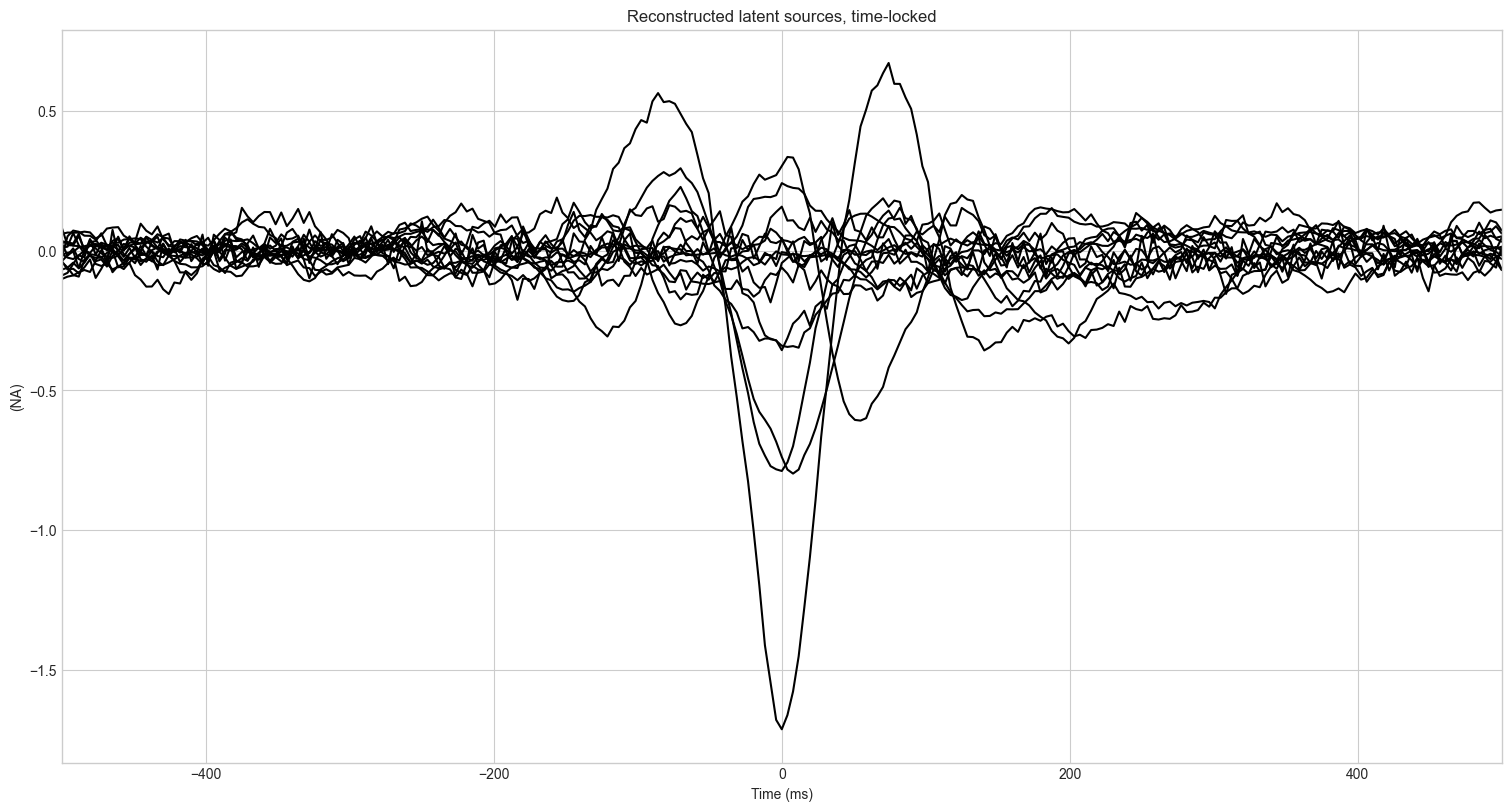

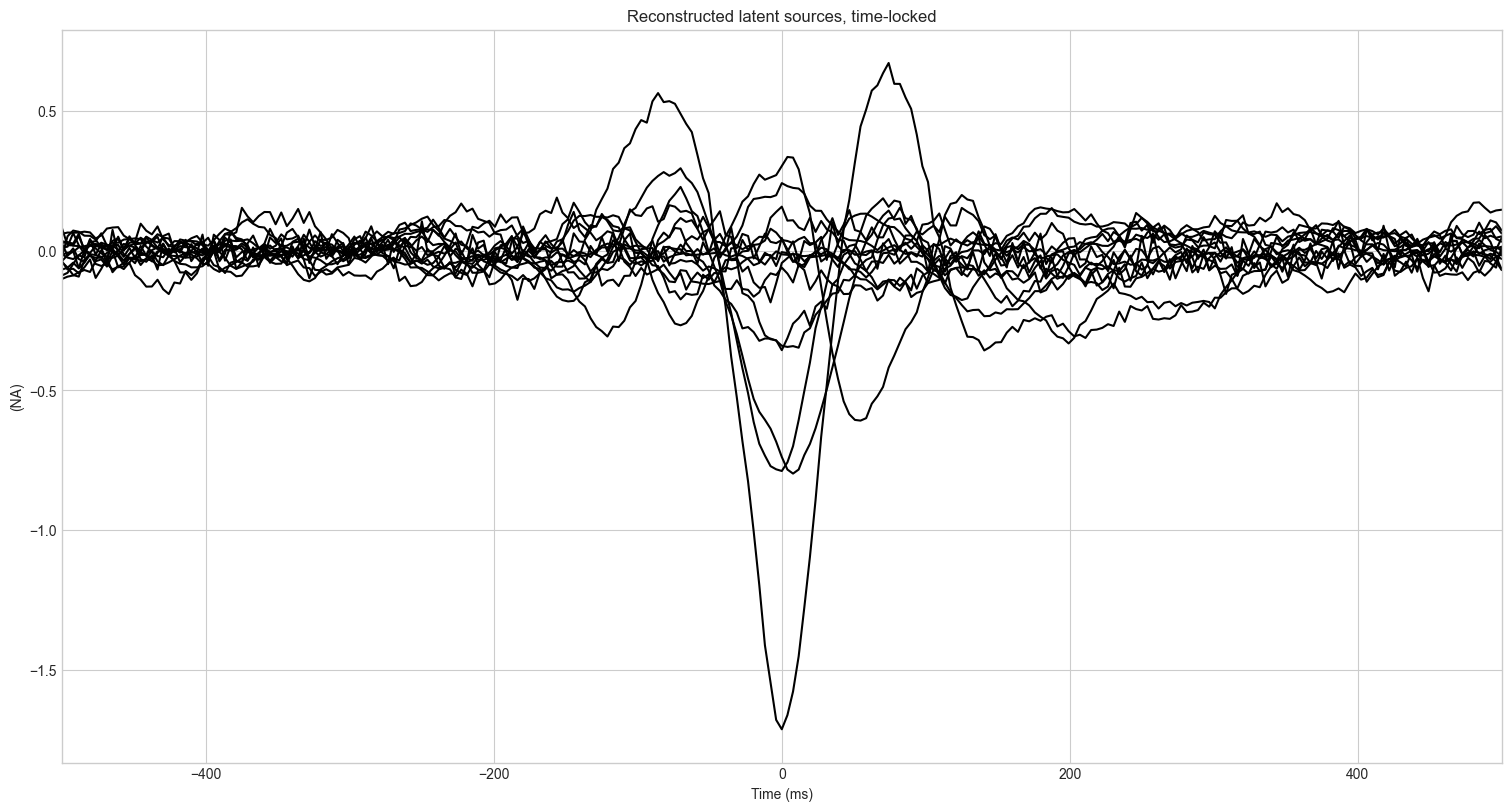

In [379]:
ica.exclude = []
# find which ICs match the EOG pattern
# Specify the EOG channels explicitly
eog_indices, eog_scores = ica.find_bads_eog(raw_awake_for_ica, ch_name=['LOC1', 'LOC2'])
ica.exclude = eog_indices

# barplot of ICA component "EOG match" scores
ica.plot_scores(eog_scores)

# plot diagnostics (only if components were found)
if len(eog_indices) > 0:
	ica.plot_properties(raw_awake_for_ica, picks=eog_indices)
else:
	print("No EOG components found automatically.")

# plot ICs applied to raw data, with EOG matches highlighted
ica.plot_sources(raw_awake_for_ica, show_scrollbars=False)

# plot ICs applied to the averaged EOG epochs, with EOG matches highlighted
ica.plot_sources(eog_evoked)